# RNN ( ReCurrent Neural Networks)

## Waste Management Dataset RNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing the neccesary libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

## Loading the Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/optimized_waste_management_data.csv')

In [4]:
df.head()

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    1461 non-null   object 
 1   waste_volume            1461 non-null   float64
 2   organic_waste           1461 non-null   float64
 3   recyclable_waste        1461 non-null   float64
 4   hazardous_waste         1461 non-null   float64
 5   collection_frequency    1461 non-null   object 
 6   landfill_capacity_used  1461 non-null   float64
 7   recycling_rate          1461 non-null   float64
dtypes: float64(6), object(2)
memory usage: 91.4+ KB


In [7]:
df.describe()

,waste_volume,organic_waste,recyclable_waste,hazardous_waste,landfill_capacity_used,recycling_rate
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,50.158919,30.135010,15.062491,4.961355,54.862266,44.393060
std,8.771361,7.635123,4.029920,1.019074,5.024692,5.267204
min,28.810000,10.480000,4.230000,1.990000,38.310000,29.140000
25%,43.660000,23.740000,11.730000,4.270000,51.570000,40.790000
50%,50.980000,30.040000,15.020000,4.970000,54.810000,44.310000
75%,56.590000,36.650000,18.330000,5.620000,58.190000,48.140000
max,70.830000,48.540000,25.160000,8.240000,71.030000,59.960000


In [14]:
df.shape

(1461, 8)

## Checking for null values

In [9]:
df.isnull().sum()

,0
date,0
waste_volume,0
organic_waste,0
recyclable_waste,0
hazardous_waste,0
collection_frequency,0
landfill_capacity_used,0
recycling_rate,0


In [17]:
df = df[['date', 'waste_volume']]

In [18]:
df.head()

,date,waste_volume
0,01-01-2020,48.85
1,02-01-2020,49.45
2,03-01-2020,51.03
3,04-01-2020,54.70
4,05-01-2020,51.74


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1461 non-null   object 
 1   waste_volume  1461 non-null   float64
dtypes: float64(1), object(1)
memory usage: 23.0+ KB


## Checking for Outliers

<Axes: >

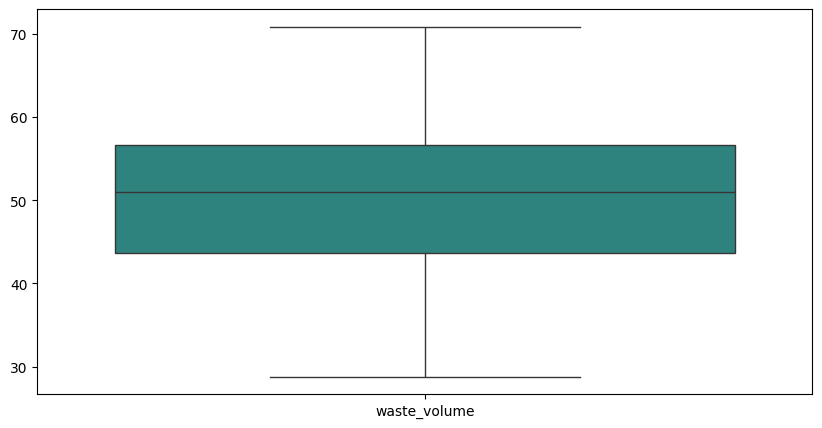

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, palette='viridis')

## Data Transformation

In [24]:
df['date'] = pd.to_datetime(df['date'], format= '%d-%m-%Y')

/tmp/ipykernel_14493/780225538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], format= '%d-%m-%Y')


In [25]:
df = df.sort_values(by='date')

## Trend of waste

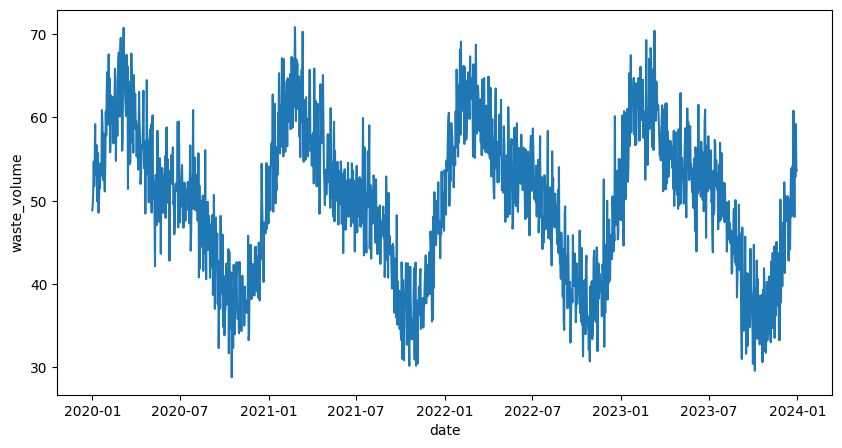

In [26]:
# waste volume trend
plt.figure(figsize=(10,5))
sns.lineplot(x='date',y='waste_volume', data=df)
plt.show()

## Normalizing the Data

In [ ]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(waste_data)